# 08 · ADAS — Automated Design of Agentic Systems

**Paper:** Shengran Hu, Cong Lu, Jeff Clune (UBC / Vector / CIFAR). *Automated Design of Agentic Systems*, **ICLR 2025**, arXiv [2408.08435](https://arxiv.org/abs/2408.08435) (`papers/2408.08435.pdf`). Algorithm: **Meta Agent Search** — a meta agent iteratively *programs* new agents in Python, evaluates them on a validation set, and appends them to an ever-growing archive that conditions the next proposal.

**Code status:** this notebook **drives the authors' repository** (`github.com/ShengranHu/ADAS` @ `2702bee`), vendored into `notebooks/vendor/ADAS` by the setup cell (gitignored, re-created on demand) and patched with `notebooks/patches/adas_openrouter.patch`. The patch is deliberately small: it builds the OpenAI client with `base_url=RCP_BASE_URL` / `api_key=OPENROUTER_API_KEY`, routes every hard-coded `gpt-3.5-turbo-0125` / `gpt-4o` id to `RCP_MODEL` (so the meta agent *and* the agents inside `forward()` use the project model), disables hidden reasoning tokens (they otherwise eat the completion budget before any code is emitted), adds a usage hook so the notebook can report tokens/cost, makes the shipped MGSM files resolve relative to the repo rather than the caller's cwd, coerces the model's answer to `str` before scoring (the repo assumes a string, while models behind an OpenAI-compatible gateway commonly return the requested integer as a JSON number — without this every answer scores 0), makes the per-call completion budget configurable via `NB_MAX_TOKENS` (default 4096, the repo's own value — OpenRouter reserves credit for the *whole* budget of every in-flight request and answers HTTP 402 when the balance is short, so a constrained account can run this notebook with `NB_MAX_TOKENS=2048`), and retries the transient 402/429/5xx statuses instead of only `RateLimitError`. Everything else — the DSL, the seed archive, the prompts, `search()`, `evaluate_forward_fn`, `bootstrap_confidence_interval` — is the authors' code, unmodified. `notebooks/adas_extras.py` holds only notebook scaffolding (fitness parsing, an argparse-free `args`, an example-set override for the transfer experiment, the pi workspace).

**Domain:** **MGSM** (Sec. 4.2, "Math"), chosen because the repo *ships* the data (`dataset/mgsm/*.tsv`, 11 languages × 250 questions, ~1 MB) — no download, no HF/blobfile access. A sparse checkout pulls only `_mgsm/`, `_transfer_math/`, `dataset/mgsm/`, `dataset/SVAMP.json` and the authors' own MGSM result archive (2.5 MB total).

**Scale.** The paper runs 30 search generations with a 128-question validation set and an 800-question held-out test set, at ≈ $300 per domain (Appendix J). This notebook runs **2–3 generations on 12 questions** for well under a dollar, using one cheap open model for every role. The absolute accuracies are therefore noisy and not comparable to the paper's tables; what is under test is that every mechanism runs end to end and produces the artefacts the paper describes.

| § | Building block | Paper ref | Code location |
|---|---|---|---|
| 1 | Agent DSL: `Info` tuples, `LLMAgentBase` (JSON output fields, role, temperature) | Sec. 3, Appendix C (framework code, < 100 lines) | `vendor/ADAS/_mgsm/search.py` |
| 2 | Seed archive of hand-designed agents + fitness = bootstrap CI | Sec. 4.1 "Baselines", Appendix F, Alg. 1 line 3 | `mgsm_prompt.get_init_archive`, `utils.bootstrap_confidence_interval` |
| 3 | Meta-agent prompt: framework code + archive + thought/name/code output format | Appendix B | `mgsm_prompt.get_prompt`, `mgsm_prompt.base` |
| 4 | Two self-reflection rounds ("refine until novel and error-free", Fig. 1) | Sec. 3, Appendix B | `mgsm_prompt.get_reflexion_prompt`, `search.search` |
| 5 | Executing model-written code, error-driven debug reflection, archive file | Sec. 3 step (3), Sec. 6 Safety, Appendix B | `search.evaluate_forward_fn`, `adas_extras.evaluate_with_debug` |
| 6 | Meta Agent Search loop and the fitness-vs-generation progression | Alg. 1 (Appendix H), Fig. 3a | `search.search` |
| 7 | Transfer of a discovered agent to held-out questions and to SVAMP | Sec. 4.3, Table 2, Appendix A Table 4 | `adas_extras.examples_override` + repo `evaluate_forward_fn` |
| 8 | LIVE `pi` session: a coding agent *is* the meta agent (writes `forward()`, runs the evaluator) | Sec. 3 ("FMs as meta agents to create new agents in code") | `common.run_pi`, `adas_extras.write_pi_workspace` |

In [1]:
import os, sys, json, time, random, difflib, textwrap
os.environ.setdefault("TQDM_DISABLE", "1")     # the repo wraps its evaluation in tqdm
sys.path.insert(0, os.path.abspath("."))
import common
from common import md, show_source, df, QUICK, USAGE, OUTPUT_DIR
import numpy as np
import matplotlib.pyplot as plt

common.banner()
E = common.env()          # exports OPENROUTER_API_KEY / RCP_MODEL / RCP_BASE_URL for the vendored repo

ADAS_COMMIT = "2702bee8fefda42255efc5be9f60e3bd3db96ae4"
VENDOR = common.ensure_repo(
    "https://github.com/ShengranHu/ADAS", ADAS_COMMIT, "ADAS",
    # non-cone sparse checkout: the MGSM domain + its shipped data + the transfer-domain code,
    # skipping the 20 MB of ARC/MMLU/GPQA/DROP data this notebook never touches.
    sparse=["--no-cone", "/_mgsm/", "/_transfer_math/", "/dataset/mgsm/", "/dataset/SVAMP.json",
            "/results/mgsm_gpt3.5_results.json", "/LICENSE", "/README.md"])
applied = common.apply_patch("patches/adas_openrouter.patch", VENDOR)
sys.path.insert(0, str(VENDOR / "_mgsm"))

import search as S           # the authors' _mgsm/search.py (patched)
import mgsm_prompt as P      # the authors' _mgsm/mgsm_prompt.py (unmodified)
import adas_extras as X      # notebook-side scaffolding
X.install_usage_hook(S, USAGE)

OUT = OUTPUT_DIR / "adas"; OUT.mkdir(exist_ok=True)
print("vendored at", VENDOR, "| patch applied now:", applied)
print("repo model resolution:", S.RCP_MODEL, "via", S.RCP_BASE_URL, "| max_tokens per call:", S.RCP_MAX_TOKENS)

# --- budgets (the paper: 128 validation questions, 30 generations, 800 held-out test questions)
EVAL_N     = 6 if QUICK else 12      # validation questions per fitness evaluation (paper: 128)
TRANSFER_N = 4 if QUICK else 8       # questions per transfer-domain evaluation
N_GEN      = 1 if QUICK else 2       # generations run by search() in §6, on top of the one in §4-5
SEED_NAMES = (["Chain-of-Thought", "Self-Consistency with Chain-of-Thought"] if QUICK else
              ["Chain-of-Thought", "Self-Consistency with Chain-of-Thought", "LLM Debate"])
ARGS = X.make_args(valid_size=EVAL_N, test_size=EVAL_N, max_workers=EVAL_N, debug_max=3,
                   model=S.RCP_MODEL, save_dir=str(OUT / "results"), expr_name="adas_mgsm")
print(f"QUICK={QUICK} | EVAL_N={EVAL_N} | generations in §6={N_GEN} | seeds evaluated={SEED_NAMES}")

Model: `deepseek/deepseek-v4-flash` via `https://openrouter.ai/api/v1` · QUICK mode: `False` · outputs → `notebooks/outputs`

vendored at /mnt/berstorage/RCP/rcp-platform/notebooks/vendor/ADAS | patch applied now: False
repo model resolution: deepseek/deepseek-v4-flash via https://openrouter.ai/api/v1 | max_tokens per call: 4096
QUICK=False | EVAL_N=12 | generations in §6=2 | seeds evaluated=['Chain-of-Thought', 'Self-Consistency with Chain-of-Thought', 'LLM Debate']


## 1 · The agent programming DSL: `Info` tuples and `LLMAgentBase` (Sec. 3, Appendix C)

> "we define a simple framework (within 100 lines of code) for the meta agent, providing it with a basic set of essential functions like querying FMs or formatting prompts. As a result, the meta agent only needs to program a 'forward' function to define a new agentic system, similar to the practice in FunSearch." — Sec. 3

The whole search space is one Python function `forward(self, taskInfo)`. Its vocabulary is two objects:

* `Info = namedtuple('Info', ['name', 'author', 'content', 'iteration_idx'])` — every message in the system is an `Info`. The task itself arrives as `Info('task', 'User', question, -1)`, and every field an agent produces comes back as an `Info` tagged with that agent's name+id and the iteration index.
* `LLMAgentBase(output_fields, agent_name, role=..., model=..., temperature=...)` — a callable FM module. `output_fields` are the JSON keys the model must return; the class builds the system prompt (`ROLE_DESC` + `FORMAT_INST`), renders the input `Info`s into a prompt, calls the model with `response_format={"type": "json_object"}`, and converts each returned field into an `Info`. Because the fields are declared, `thinking, answer = agent([taskInfo], instruction)` unpacks positionally.

Robustness is part of the DSL: if the model returns too few/too many fields, `query()` pads or trims them rather than raising, and a context-length error is turned into an `AssertionError` telling the meta agent to design a shorter-context agent.

In [2]:
show_source(S.LLMAgentBase)
print("Info fields:", S.Info._fields)
print("FORMAT_INST({'thinking': ..., 'answer': ...}) ->\n", S.FORMAT_INST({'thinking': 'Your thinking.', 'answer': 'Your answer.'}))

**LLMAgentBase**

```python
class LLMAgentBase():
    """
    Attributes:
    """

    def __init__(self, output_fields: list, agent_name: str,
                 role='helpful assistant', model=None, temperature=0.5) -> None:
        self.output_fields = output_fields
        self.agent_name = agent_name

        self.role = role
        self.model = model
        self.temperature = temperature

        # give each instance a unique id
        self.id = random_id()

    def generate_prompt(self, input_infos, instruction) -> str:
        # construct system prompt
        output_fields_and_description = {key: f"Your {key}." if not 'answer' in key else f"Your {key}. Return ONLY an integer. DO NOT return anything other than the integer answer." for key in self.output_fields}
        system_prompt = ROLE_DESC(self.role) + "\n\n" + FORMAT_INST(output_fields_and_description)

        # construct input infos text
        input_infos_text = ''
        for input_info in input_infos:
            if isinstance(input_info, Info):
                (field_name, author, content, iteration_idx) = input_info
            else:
                continue
            if author == self.__repr__():
                author += ' (yourself)'
            if field_name == 'task':
                input_infos_text += f'# Your Task:\n{content}\n\n'
            elif iteration_idx != -1:
                input_infos_text += f'### {field_name} #{iteration_idx + 1} by {author}:\n{content}\n\n'
            else:
                input_infos_text += f'### {field_name} by {author}:\n{content}\n\n'

        prompt = input_infos_text + instruction
        return system_prompt, prompt

    def query(self, input_infos: list, instruction, iteration_idx=-1) -> dict:
        system_prompt, prompt = self.generate_prompt(input_infos, instruction)
        try:
            response_json = {}
            response_json = get_json_response_from_gpt(prompt, self.model, system_prompt, self.temperature)
            assert len(response_json) == len(self.output_fields), "not returning enough fields"
        except Exception as e:
            # print(e)
            if "maximum context length" in str(e) and SEARCHING_MODE:
                raise AssertionError("The context is too long. Please try to design the agent to have shorter context.")
            # try to fill in the missing field
            for key in self.output_fields:
                if not key in response_json and len(response_json) < len(self.output_fields):
                    response_json[key] = ''
            for key in copy.deepcopy(list(response_json.keys())):
                if len(response_json) > len(self.output_fields) and not key in self.output_fields:
                    del response_json[key]
        output_infos = []
        for key, value in response_json.items():
            info = Info(key, self.__repr__(), value, iteration_idx)
            output_infos.append(info)
        return output_infos

    def __repr__(self):
        return f"{self.agent_name} {self.id}"

    def __call__(self, input_infos: list, instruction, iteration_idx=-1):
        return self.query(input_infos, instruction, iteration_idx=iteration_idx)

```

Info fields: ('name', 'author', 'content', 'iteration_idx')
FORMAT_INST({'thinking': ..., 'answer': ...}) ->
 Reply EXACTLY with the following JSON format.
{'thinking': 'Your thinking.', 'answer': 'Your answer.'}
DO NOT MISS ANY REQUEST FIELDS and ensure that your response is a well-formed JSON object!



### The questions: MGSM as shipped in the repo

`utils.get_all_examples()` concatenates the 11 language files (250 questions each) and prefixes each with a localised "Solve this math problem." instruction. `evaluate_forward_fn` then shuffles with `shuffle_seed=0` and takes the first `valid_size` as the validation set — exactly the split reproduced below.

In [3]:
ALL_EX = S.get_all_examples()
VALID = X.mgsm_examples(S, ARGS, "valid")
print(f"{len(ALL_EX)} MGSM questions, languages {sorted({e['lang'] for e in ALL_EX})}")
display(df([{"lang": e["lang"], "question": e["inputs"].replace(chr(10), " ")[:90], "target": e["targets"]} for e in VALID]))

2750 MGSM questions, languages ['bn', 'de', 'en', 'es', 'fr', 'ja', 'ru', 'sw', 'te', 'th', 'zh']


,lang,question,target
0,th,แก้ปัญหาคณิตศาสตร์นี้ พ่อค้าคนหนึ่งต้องเลือกร...,125
1,zh,解决这个数学问题。 罗素在一家宠物店工作，并且正在给啮齿动物分配秸秆。老鼠以每组相同的数量...,5
2,de,Löse dieses Mathematikproblem. Jerry hat eine...,4
3,zh,解决这个数学问题。 史蒂芬在网上下单购买生活用品。他的最终账单金额是 40.00 美元。因...,57
4,te,ఈ గణిత సమస్యను పరిష్కరించండి. క్యాండీ మెషిన్‌...,70
5,ru,Решите эту математическую задачу. Мэри — заяд...,58
6,ja,この数学の問題を解いてください。 バスケットボールの大会で、4校が競っている。各学校が女子...,48
7,th,แก้ปัญหาคณิตศาสตร์นี้ เพลงแรกของมาริลีนมียอดจ...,8000
8,sw,Suluhisha tatizo hili la hesabu. Kylar aliend...,64
9,ja,"この数学の問題を解いてください。 ソーダ市には住民が23,786人いる。これには8,417...",6277


### One agent, one question — the `Info` flow

Below: a single `LLMAgentBase` with output fields `['thinking', 'answer']` is asked one MGSM question, then a second agent with fields `['feedback', 'correct']` and the role *Critic Agent* receives **the first agent's `Info`s** as input. The rendered prompt shows how `Info`s become the `### <field> by <author>:` blocks that carry state between modules — this is the entire message-passing mechanism the meta agent programs with.

In [4]:
taskInfo = S.Info('task', 'User', VALID[0]['inputs'], -1)
cot_agent = S.LLMAgentBase(['thinking', 'answer'], 'Chain-of-Thought Agent', temperature=0.5)
sys_p, user_p = cot_agent.generate_prompt([taskInfo], "Please think step by step and then solve the task.")
print("agent repr:", repr(cot_agent), "| role:", cot_agent.role, "| temperature:", cot_agent.temperature)
print("\n--- system prompt ---\n" + sys_p)
print("--- user prompt ---\n" + user_p[:600])

agent repr: Chain-of-Thought Agent Lu3e | role: helpful assistant | temperature: 0.5

--- system prompt ---
You are a helpful assistant.

Reply EXACTLY with the following JSON format.
{'thinking': 'Your thinking.', 'answer': 'Your answer. Return ONLY an integer. DO NOT return anything other than the integer answer.'}
DO NOT MISS ANY REQUEST FIELDS and ensure that your response is a well-formed JSON object!

--- user prompt ---
# Your Task:
แก้ปัญหาคณิตศาสตร์นี้

พ่อค้าคนหนึ่งต้องเลือกระหว่างแผนการซื้อ 2 แผน ได้แก่ เครื่องประดับมูลค่า $5,000 หรืออุปกรณ์อิเล็กทรอนิกส์มูลค่า $8,000 ที่ปรึกษาด้านการเงินของเขาคาดการณ์ว่าตลาดเครื่องประดับจะมีมูลค่าสูงขึ้น 2.5% ส่วนตลาดอุปกรณ์อิเล็กทรอนิกส์จะมีมูลค่าสูงขึ้น 1.2% ภายในเดือนเดียวกัน ถ้าพ่อค้าต้องการเลือกแผนที่ทำกำไรสูงสุดภายในสิ้นเดือนนี้ พ่อค้าจะได้กำไรกี่ดอลลาร์

Please think step by step and then solve the task.


In [5]:
thinking, answer = cot_agent([taskInfo], "Please think step by step and then solve the task.")
display(df([{"name": i.name, "author": i.author, "iteration_idx": i.iteration_idx, "content": str(i.content)[:120]}
            for i in (taskInfo, thinking, answer)]))
print("gold:", VALID[0]['targets'], "| scored correct:", S.score_mgsm(VALID[0]['targets'], str(answer.content)))

,name,author,iteration_idx,content
0,task,User,-1,แก้ปัญหาคณิตศาสตร์นี้\n\nพ่อค้าคนหนึ่งต้องเลือ...
1,thinking,Chain-of-Thought Agent Lu3e,-1,Calculate the profit for each plan. Jewelry: $...
2,answer,Chain-of-Thought Agent Lu3e,-1,125


gold: 125 | scored correct: True


In [6]:
critic = S.LLMAgentBase(['feedback', 'correct'], 'Critic Agent', role='Math Professor', temperature=0.3)
csys, cuser = critic.generate_prompt([taskInfo, thinking, answer],
                                     "Please review the answer above and criticize on where might be wrong. "
                                     "If you are absolutely sure it is correct, output 'True' in 'correct'.")
print("--- how the previous agent's Infos are rendered into the critic's prompt ---\n")
print(cuser[:1200])
feedback, correct = critic([taskInfo, thinking, answer],
                           "Please review the answer above and criticize on where might be wrong. "
                           "If you are absolutely sure it is correct, output 'True' in 'correct'.", 0)
display(df([{"name": i.name, "author": i.author, "iteration_idx": i.iteration_idx, "content": str(i.content)[:160]}
            for i in (feedback, correct)]))

--- how the previous agent's Infos are rendered into the critic's prompt ---

# Your Task:
แก้ปัญหาคณิตศาสตร์นี้

พ่อค้าคนหนึ่งต้องเลือกระหว่างแผนการซื้อ 2 แผน ได้แก่ เครื่องประดับมูลค่า $5,000 หรืออุปกรณ์อิเล็กทรอนิกส์มูลค่า $8,000 ที่ปรึกษาด้านการเงินของเขาคาดการณ์ว่าตลาดเครื่องประดับจะมีมูลค่าสูงขึ้น 2.5% ส่วนตลาดอุปกรณ์อิเล็กทรอนิกส์จะมีมูลค่าสูงขึ้น 1.2% ภายในเดือนเดียวกัน ถ้าพ่อค้าต้องการเลือกแผนที่ทำกำไรสูงสุดภายในสิ้นเดือนนี้ พ่อค้าจะได้กำไรกี่ดอลลาร์

### thinking by Chain-of-Thought Agent Lu3e:
Calculate the profit for each plan. Jewelry: $5,000 * 2.5% = $125. Electronics: $8,000 * 1.2% = $96. The maximum profit is $125 from jewelry.

### answer by Chain-of-Thought Agent Lu3e:
125

Please review the answer above and criticize on where might be wrong. If you are absolutely sure it is correct, output 'True' in 'correct'.


,name,author,iteration_idx,content
0,feedback,Critic Agent Xjgq,0,การคำนวณกำไรของแต่ละแผนถูกต้องแล้ว เครื่องประด...
1,correct,Critic Agent Xjgq,0,True


## 2 · The seed archive and the fitness statistic (Sec. 4.1 Baselines, Appendix F)

> "We also use all baselines as initial seeds in the archive for Meta Agent Search... To ensure fair comparisons, all baseline implementations were developed using the same framework as the Meta Agent" — Sec. 4.1

`get_init_archive()` returns seven hand-designed agents written in the same DSL, each a `{thought, name, code}` dict: **Chain-of-Thought**, **Self-Consistency with CoT** (N=5 samples, majority vote), **Self-Refine / Reflexion** (critic loop, ≤5 rounds), **LLM-Debate** (3 roles × 2 rounds + a final decision agent), **Step-back Abstraction**, **Quality-Diversity** (3 diverse attempts + ensemble) and **Dynamic Assignment of Roles** (a routing agent picks the expert). Appendix I shows the search also works from an *empty* archive, so seeding is an optimisation, not a requirement.

**Fitness.** `bootstrap_confidence_interval(acc_list)` resamples the 0/1 per-question accuracies 100 000 times and returns the string that the archive stores and the meta agent reads:
`95% Bootstrap Confidence Interval: (lo%, hi%), Median: med%`. The paper's tables report this as `median ± half-width`.

In [7]:
INIT = P.get_init_archive()
display(df([{"name": s["name"], "code lines": len(s["code"].splitlines()),
             "thought": " ".join(s["thought"].split())[:110]} for s in INIT]))

,name,code lines,thought
0,Chain-of-Thought,18,By encouraging the LLM to think step by step r...
1,Self-Consistency with Chain-of-Thought,21,"While an LLM can arrive at the correct answer,..."
2,Self-Refine (Reflexion),30,"To enhance its performance, an LLM can iterati..."
3,LLM Debate,32,By letting different LLMs debate with each oth...
4,Step-back Abstraction,17,Let LLM first think about the principles invol...
5,Quality-Diversity,33,"Similar to Quality-Diversity methods, let LLM ..."
6,Dynamic Assignment of Roles,23,"Similar to Auto-GPT and expert prompting, we c..."


In [8]:
for name in ("Chain-of-Thought", "Self-Consistency with Chain-of-Thought", "LLM Debate"):
    s = next(x for x in INIT if x["name"] == name)
    md(f"**Seed agent · {s['name']}**\n\n```python\n{s['code'].strip()}\n```")

**Seed agent · Chain-of-Thought**

```python
def forward(self, taskInfo):
    # Instruction for the Chain-of-Thought (CoT) approach
    # It is an important practice that allows the LLM to think step by step before solving the task.
    cot_instruction = "Please think step by step and then solve the task."

    # Instantiate a new LLM agent specifically for CoT
    # To allow LLM thinking before answering, we need to set an additional output field 'thinking'.
    cot_agent = LLMAgentBase(['thinking', 'answer'], 'Chain-of-Thought Agent')

    # Prepare the inputs for the CoT agent
    # The input should be a list of Info, and the first one is often the taskInfo
    cot_agent_inputs = [taskInfo]

    # Get the response from the CoT agent
    thinking, answer = cot_agent(cot_agent_inputs, cot_instruction)

    # Return only the final answer
    return answer
```

**Seed agent · Self-Consistency with Chain-of-Thought**

```python
def forward(self, taskInfo):
    # Instruction for step-by-step reasoning
    cot_instruction = "Please think step by step and then solve the task."
    N = 5 # Number of CoT agents

    # Initialize multiple CoT agents with a higher temperature for varied reasoning
    cot_agents = [LLMAgentBase(['thinking', 'answer'], 'Chain-of-Thought Agent', temperature=0.8) for _ in range(N)]

    # Majority voting function to select the most common answer
    from collections import Counter
    def majority_voting(answers):
        return Counter(answers).most_common(1)[0][0]
    
    possible_answers = []
    for i in range(N):
        thinking, answer = cot_agents[i]([taskInfo], cot_instruction)
        possible_answers.append(answer.content)

    # Ensembling the answers from multiple CoT agents
    answer = majority_voting(possible_answers)
    return answer
```

**Seed agent · LLM Debate**

```python
def forward(self, taskInfo):
    # Instruction for initial reasoning
    debate_initial_instruction = "Please think step by step and then solve the task."

    # Instruction for debating and updating the solution based on other agents' solutions
    debate_instruction = "Given solutions to the problem from other agents, consider their opinions as additional advice. Please think carefully and provide an updated answer."
    
    # Initialize debate agents with different roles and a moderate temperature for varied reasoning
    debate_agents = [LLMAgentBase(['thinking', 'answer'], 'Debate Agent', temperature=0.8, role=role) for role in ['Math Professor', 'Grade School Teacher', 'Math Enthusiast']]

    # Instruction for final decision-making based on all debates and solutions
    final_decision_instruction = "Given all the above thinking and answers, reason over them carefully and provide a final answer."
    final_decision_agent = LLMAgentBase(['thinking', 'answer'], 'Final Decision Agent', temperature=0.1)

    max_round = 2 # Maximum number of debate rounds
    all_thinking = [[] for _ in range(max_round)]
    all_answer = [[] for _ in range(max_round)]

    # Perform debate rounds
    for r in range(max_round):
        for i in range(len(debate_agents)):
            if r == 0:
                thinking, answer = debate_agents[i]([taskInfo], debate_initial_instruction)
            else:
                input_infos = [taskInfo] + [all_thinking[r-1][i]] + all_thinking[r-1][:i] + all_thinking[r-1][i+1:]
                thinking, answer = debate_agents[i](input_infos, debate_instruction)
            all_thinking[r].append(thinking)
            all_answer[r].append(answer)
    
    # Make the final decision based on all debate results and solutions
    thinking, answer = final_decision_agent([taskInfo] + all_thinking[max_round-1] + all_answer[max_round-1], final_decision_instruction)
    return answer
```

### Boundary check on the fitness statistic (pure Python, no LLM)

The CI must collapse on unanimous data and widen on split data; the median is the bootstrap median of the mean, not the raw mean.

In [9]:
rows = []
for label, accs in [("all correct (n=12)", [1]*12), ("all wrong (n=12)", [0]*12),
                    ("6/12", [1]*6 + [0]*6), ("6/12 but n=4 (2/4)", [1, 1, 0, 0]),
                    ("11/12", [1]*11 + [0])]:
    f = S.bootstrap_confidence_interval(accs)
    rows.append({"data": label, "raw mean %": 100*np.mean(accs), "fitness string": f, "paper format": X.fitness_pm(f)})
display(df(rows))

,data,raw mean %,fitness string,paper format
0,all correct (n=12),100.000000,"95% Bootstrap Confidence Interval: (100.0%, 10...",100.0 ± 0.0
1,all wrong (n=12),0.000000,"95% Bootstrap Confidence Interval: (0.0%, 0.0%...",0.0 ± 0.0
2,6/12,50.000000,"95% Bootstrap Confidence Interval: (25.0%, 75....",50.0 ± 25.0
3,6/12 but n=4 (2/4),50.000000,"95% Bootstrap Confidence Interval: (0.0%, 100....",50.0 ± 50.0
4,11/12,91.666667,"95% Bootstrap Confidence Interval: (75.0%, 100...",91.7 ± 12.5


### Evaluating seed agents with the paper's evaluation function

`evaluate_forward_fn` is the whole evaluation pipeline: `exec` the candidate's code string, assert it defines exactly one callable, bind it as `AgentSystem.forward`, build the shuffled validation split, and map the agent over the questions with a thread pool. Each seed below is scored on the **same** `EVAL_N` questions, so the fitness numbers are comparable to each other and to everything discovered later.

In [10]:
S.SEARCHING_MODE = True
ARCHIVE = []
for name in SEED_NAMES:
    sol = dict(next(x for x in INIT if x["name"] == name))
    t0 = time.time(); n0 = USAGE.requests
    acc = S.evaluate_forward_fn(ARGS, sol["code"])
    sol["fitness"] = S.bootstrap_confidence_interval(acc)
    sol["generation"] = "initial"
    ARCHIVE.append(sol)
    print(f"{name:45s} acc={acc} {USAGE.requests-n0:3d} calls {time.time()-t0:5.0f}s\n  {sol['fitness']}\n")
display(df(X.archive_rows(ARCHIVE)))

problem length: 12


acc: 95% Bootstrap Confidence Interval: (58.3%, 100.0%), Median: 83.3%


Chain-of-Thought                              acc=[1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1]  12 calls    16s
  95% Bootstrap Confidence Interval: (58.3%, 100.0%), Median: 83.3%

problem length: 12


acc: 95% Bootstrap Confidence Interval: (50.0%, 100.0%), Median: 75.0%


Self-Consistency with Chain-of-Thought        acc=[1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1]  60 calls   668s
  95% Bootstrap Confidence Interval: (50.0%, 100.0%), Median: 75.0%

problem length: 12


acc: 95% Bootstrap Confidence Interval: (50.0%, 100.0%), Median: 75.0%


LLM Debate                                    acc=[1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1]  84 calls   119s
  95% Bootstrap Confidence Interval: (50.0%, 100.0%), Median: 75.0%



,idx,generation,name,median %,95% CI,median ± CI/2,code lines
0,0,initial,Chain-of-Thought,83.3,"(58.3, 100.0)",83.3 ± 20.9,18
1,1,initial,Self-Consistency with Chain-of-Thought,75.0,"(50.0, 100.0)",75.0 ± 25.0,21
2,2,initial,LLM Debate,75.0,"(50.0, 100.0)",75.0 ± 25.0,32


## 3 · The meta-agent prompt (Appendix B)

`get_prompt(current_archive)` returns `(system_prompt, prompt)`. The system prompt is one line — *"You are a helpful assistant. Make sure to return in a WELL-FORMED JSON object."* The user prompt is assembled from five parts, in this order:

1. **Domain description** — the objective ("design an optimal agent performing well on the Multilingual Grade School Math Benchmark (MGSM)...") plus a sample question. This is the *only* part that differs between the paper's five domains.
2. **The utility / framework code** — the same `Info`, `FORMAT_INST`, `LLMAgentBase`, `get_json_response_from_gpt` shown in §1, given to the meta agent as documentation, ending with an `AgentArchitecture` stub whose `forward` is to be filled in.
3. **The discovered-architecture archive** — every entry serialised as JSON (`thought`, `name`, `code`, `fitness`), with the explicit instruction: *"The fitness value is the median and 95% Bootstrap Confidence Interval of the correct rate on a validation question set. Your GOAL is to maximize the 'fitness'."*
4. **Output instruction and example** — the three keys `thought` / `name` / `code`, where `thought` itself is templated as `**Insights:** … **Overall Idea:** … **Implementation:** …`.
5. **`## WRONG Implementation examples`** — four concrete DSL mistakes (constructing `Info` by hand, `len()` on the returned list, printing, extracting `.content` instead of passing `Info`s on). The paper leaves this block as a placeholder; the repo fills it in, and Appendix B notes it was "effective in improving the quality of the generated code".

In [11]:
sys_prompt, meta_prompt = P.get_prompt(ARCHIVE)
print("system prompt:", repr(sys_prompt))
print(f"user prompt: {len(meta_prompt)} chars ≈ {len(meta_prompt)//4} tokens, archive of {len(ARCHIVE)} agents")
marks = {"domain description": 0, "utility code": meta_prompt.find("# The utility code:"),
         "archive": meta_prompt.find("# Discovered architecture archive"),
         "output instruction": meta_prompt.find("# Output Instruction and Example:"),
         "wrong examples": meta_prompt.find("## WRONG Implementation examples:"),
         "your task": meta_prompt.find("# Your task")}
ordered = sorted(marks.items(), key=lambda kv: kv[1])
bounds = [v for _, v in ordered] + [len(meta_prompt)]
display(df([{"section": k, "char offset": v, "chars": bounds[i+1] - v} for i, (k, v) in enumerate(ordered)]))

system prompt: 'You are a helpful assistant. Make sure to return in a WELL-FORMED JSON object.'
user prompt: 16710 chars ≈ 4177 tokens, archive of 3 agents


,section,char offset,chars
0,domain description,0,642
1,utility code,642,6037
2,archive,6679,5217
3,output instruction,11896,1720
4,wrong examples,13616,2440
5,your task,16056,654


In [12]:
print(meta_prompt[:marks["utility code"]])
print("... [framework code: %d chars, shown in §1] ...\n" % (marks["archive"] - marks["utility code"]))
print(meta_prompt[marks["archive"]:marks["archive"]+400])
print("   ... one JSON object per archived agent, e.g. keys:",
      list(json.loads("[" + ",".join(json.dumps(s) for s in ARCHIVE) + "]")[0].keys()))
print()
print(meta_prompt[marks["output instruction"]:marks["wrong examples"]][:1800])

# Overview
You are an expert machine learning researcher testing various agentic systems. Your objective is to design building blocks such as prompts and control flows within these systems to solve complex tasks. Your aim is to design an optimal agent performing well on the Multilingual Grade School Math Benchmark (MGSM) which evaluates mathematical problem-solving abilities across various languages to ensure broad and effective multilingual performance.

## An example question from MGSM:

**Question**: この数学の問題を解いてください。

近所では、ペットのウサギの数がペットの犬と猫を合わせた数よりも12匹少ない。犬1匹あたり2匹の猫がおり、犬の数は60匹だとすると、全部で近所には何匹のペットがいますか？

**Answer (Not Given)**: 348


... [framework code: 6037 chars, shown in §1] ...

# Discovered architecture archive
Here is the archive of the discovered architectures:

[{"thought": "By encouraging the LLM to think step by step rather than directly outputting an answer, chain-of-thought reasoning enables complex problem-solving through intermediate steps. This practice improves the mo

In [13]:
print(meta_prompt[marks["your task"]:])

# Your task
You are deeply familiar with LLM prompting techniques and LLM agent works from the literature. Your goal is to maximize "fitness" by proposing interestingly new agents. 
Observe the discovered architectures carefully and think about what insights, lessons, or stepping stones can be learned from them.
Be creative to think about the next interesting architecture to try. You are encouraged to draw inspiration from related LLM agent papers or academic papers from other research areas.
Using the knowledge learned from the archive and the inspiration from academic literature to give the next interesting architecture.
THINK OUTSIDE THE BOX.



## 4 · The two reflection rounds (Sec. 3, Appendix B, the self-loop in Fig. 1)

> "The design then undergoes two self-reflection steps by the meta agent to ensure it is novel" — Sec. 3

After the first proposal the chat is continued twice, and each reply must be a JSON object with a `reflection` key in addition to `thought` / `name` / `code`:

* **Reflexion 1** — asks for (1) *Interestingness* ("Compare the proposal and the architectures in the archive CAREFULLY... USE CRITICAL THINKING!"), (2) *Implementation Mistakes* (re-check against the WRONG-examples block), (3) *Improvement*. It is prefixed with the previously proposed agent when one exists (`get_reflexion_prompt(archive[-1] if n > 0 else None)`).
* **Reflexion 2** — one short paragraph: re-apply the WRONG-examples tips, repeat `thought`/`name`, and output the corrected `code`.

A **third**, error-triggered reflection exists as well; it is driven by evaluation failures and appears in §5.

In [14]:
r1, r2 = P.get_reflexion_prompt(ARCHIVE[-1])
print("--- Reflexion prompt 1 (with the previous agent prefixed) ---")
print(r1[:700], "\n   ...\n", r1[-1500:])
print("\n--- Reflexion prompt 2 ---")
print(r2)

--- Reflexion prompt 1 (with the previous agent prefixed) ---
"Here is the previous agent you tried:
{"thought": "By letting different LLMs debate with each other, we can leverage their diverse perspectives to find better solutions for tasks.", "name": "LLM Debate", "code": "def forward(self, taskInfo):\n    # Instruction for initial reasoning\n    debate_initial_instruction = \"Please think step by step and then solve the task.\"\n\n    # Instruction for debating and updating the solution based on other agents' solutions\n    debate_instruction = \"Given solutions to the problem from other agents, consider their opinions as additional advice. Please think carefully and provide an updated answer.\"\n    \n    # Initialize debate agents with different r 
   ...
  you find, and provide a corrected version. REMEMBER checking "## WRONG Implementation examples" in the prompt.

3. **Improvement**: Based on the proposed architecture, suggest improvements in the detailed implementation that co

In [15]:
t0 = time.time()
STAGES, MSG_LIST = X.meta_propose(S, P, ARCHIVE, ARGS.model, prev_example=None)
print(f"3 meta-agent calls in {time.time()-t0:.0f}s\n")
display(df([{"stage": s, "keys": list(v.keys()), "name": v.get("name"), "code lines": len(v["code"].splitlines())}
            for s, v in zip(["proposal", "after reflexion 1", "after reflexion 2"], STAGES)]))

3 meta-agent calls in 114s



,stage,keys,name,code lines
0,proposal,"[thought, name, code]",Verifier-Refiner with Iterative Correction,29
1,after reflexion 1,"[reflection, thought, name, code]",Verifier-Refiner,36
2,after reflexion 2,"[reflection, thought, name, code]",Verifier-Refiner,36


In [16]:
md("**Proposal (`thought`, truncated)**\n\n> " + " ".join(STAGES[0]["thought"].split())[:900])
for i, label in [(1, "reflexion 1"), (2, "reflexion 2")]:
    md(f"**`reflection` written in {label}**\n\n> " + " ".join(str(STAGES[i].get("reflection", "")).split())[:900])
    diff = list(difflib.unified_diff(STAGES[i-1]["code"].splitlines(), STAGES[i]["code"].splitlines(),
                                     fromfile=f"before {label}", tofile=f"after {label}", lineterm="", n=1))
    md(f"**code diff across {label}** ({len(diff)} diff lines)\n\n```diff\n" + "\n".join(diff[:60]) + "\n```")

**Proposal (`thought`, truncated)**

> **Insights:** The existing architectures (CoT, Self-Consistency, and LLM Debate) rely on generating reasoning traces and combining them. However, they don't include a verification step to catch and correct mistakes. In math problems, errors can propagate; a verifier that critiques the answer and a mechanism to revise it could improve accuracy. This is inspired by the 'Self-Refine' and 'Critique-and-Revise' literature, where iterative feedback loops lead to better outputs. **Overall Idea:** Introduce a 'Verifier-Refiner' architecture where an initial CoT agent produces a solution. Then, a separate 'Verifier' agent (with a different role, e.g., 'Math Professor') checks the reasoning and answer for correctness, providing detailed feedback. If the verifier identifies an error, a 'Refiner' agent uses the feedback to produce a revised solution. This process is repeated for a fixed number of ro

**`reflection` written in reflexion 1**

> **Interestingness**: The proposed Verifier-Refiner architecture is interesting because it introduces a verification and correction loop, which is a clear step beyond the existing CoT, Self-Consistency, and Debate methods. However, it is not entirely novel as it resembles self-refine techniques. It could be made more innovative by incorporating a multi-agent debate style verification where multiple verifiers vote, similar to the LLM Debate but with a correction step. However, the current proposal is reasonably innovative given the archive, so I'll keep the core idea but improve implementation details. **Implementation Mistakes**: 1. The verifier instruction says 'respond with is_correct: yes/no', but the output field is 'is_correct' which expects a string. The agent will return an Info object with content that may not be exactly 'yes' or 'no'. I should instruct the verifier to output exac

**code diff across reflexion 1** (41 diff lines)

```diff
--- before reflexion 1
+++ after reflexion 1
@@ -1,3 +1,3 @@
 def forward(self, taskInfo):
-    # Initial reasoning step
+    # Initial reasoning via Chain-of-Thought
     cot_instruction = "Please think step by step and then solve the task."
@@ -6,8 +6,14 @@
 
-    # Verifier agent to check correctness
-    verifier_instruction = "You are a strict verifier. Check the provided solution carefully. If the answer is correct, respond with 'is_correct: yes' and provide brief positive feedback. If incorrect, respond with 'is_correct: no' and provide specific feedback on what is wrong and how to fix it."
+    # Verifier to check correctness
+    verifier_instruction = (
+        "You are a strict math verifier. Given the solution (thinking and answer), check if it is correct. "
+        "Provide detailed feedback on any errors. Your 'is_correct' field must be EXACTLY 'yes' or 'no' (lowercase)."
+    )
     verifier_agent = LLMAgentBase(['feedback', 'is_correct'], 'Verifier', role='Math Professor', temperature=0.2)
 
-    # Refiner agent to revise based on feedback
-    refiner_instruction = "You are a careful refiner. Given the feedback from a verifier, revise the solution to correct any mistakes. Think step by step and provide an updated answer."
+    # Refiner to revise based on feedback
+    refiner_instruction = (
+        "You are a careful refiner. You are given the original problem, the previous solution, and feedback from a verifier. "
+        "Revise the solution to correct any mistakes. Think step by step and provide an updated answer."
+    )
     refiner_agent = LLMAgentBase(['thinking', 'answer'], 'Refiner', role='Grade School Teacher', temperature=0.4)
@@ -19,8 +25,9 @@
     for round_idx in range(max_rounds):
-        # Verify current solution
-        feedback, is_correct = verifier_agent([taskInfo, current_thinking, current_answer], verifier_instruction)
-        if is_correct.content.strip().lower() == 'yes':
+        # Get verification
+        feedback_info, is_correct_info = verifier_agent([taskInfo, current_thinking, current_answer], verifier_instruction)
+        is_correct = is_correct_info.content.strip().lower()
+        if is_correct == 'yes':
             break
-        # Refine based on feedback
-        new_thinking, new_answer = refiner_agent([taskInfo, current_thinking, current_answer, feedback], refiner_instruction)
+        # Refine if incorrect
+        new_thinking, new_answer = refiner_agent([taskInfo, current_thinking, current_answer, feedback_info], refiner_instruction)
         current_thinking = new_thinking
```

**`reflection` written in reflexion 2**

> Upon reviewing the code and the WRONG Implementation examples, I identified several issues: 1. **Incorrect handling of verifier output**: The verifier returns a list of Info objects. In the code, I wrote `feedback_info, is_correct_info = verifier_agent(...)`, which assumes the list has exactly two elements. However, the LLMAgentBase returns a list, and unpacking it this way is correct only if the order matches the output_fields. Since output_fields is ['feedback', 'is_correct'], the first element is feedback and second is is_correct. This is fine, but I need to be careful that the list length matches. The code is acceptable. 2. **Extracting content from Info objects**: I used `.content` to get the string value of is_correct_info. According to the WRONG examples, we should not extract content manually. However, the examples show that when aggregating inputs for the next LLM, we should pas

**code diff across reflexion 2** (7 diff lines)

```diff
--- before reflexion 2
+++ after reflexion 2
@@ -25,3 +25,3 @@
     for round_idx in range(max_rounds):
-        # Get verification
+        # Get verification results
         feedback_info, is_correct_info = verifier_agent([taskInfo, current_thinking, current_answer], verifier_instruction)
```

In [17]:
NEXT = STAGES[-1]
md(f"**Proposed agent after both reflections · {NEXT['name']}**\n\n```python\n{NEXT['code'].strip()}\n```")

**Proposed agent after both reflections · Verifier-Refiner**

```python
def forward(self, taskInfo):
    # Initial reasoning via Chain-of-Thought
    cot_instruction = "Please think step by step and then solve the task."
    cot_agent = LLMAgentBase(['thinking', 'answer'], 'Chain-of-Thought Agent')
    thinking, answer = cot_agent([taskInfo], cot_instruction)

    # Verifier to check correctness
    verifier_instruction = (
        "You are a strict math verifier. Given the solution (thinking and answer), check if it is correct. "
        "Provide detailed feedback on any errors. Your 'is_correct' field must be EXACTLY 'yes' or 'no' (lowercase)."
    )
    verifier_agent = LLMAgentBase(['feedback', 'is_correct'], 'Verifier', role='Math Professor', temperature=0.2)

    # Refiner to revise based on feedback
    refiner_instruction = (
        "You are a careful refiner. You are given the original problem, the previous solution, and feedback from a verifier. "
        "Revise the solution to correct any mistakes. Think step by step and provide an updated answer."
    )
    refiner_agent = LLMAgentBase(['thinking', 'answer'], 'Refiner', role='Grade School Teacher', temperature=0.4)

    max_rounds = 2
    current_thinking = thinking
    current_answer = answer

    for round_idx in range(max_rounds):
        # Get verification results
        feedback_info, is_correct_info = verifier_agent([taskInfo, current_thinking, current_answer], verifier_instruction)
        is_correct = is_correct_info.content.strip().lower()
        if is_correct == 'yes':
            break
        # Refine if incorrect
        new_thinking, new_answer = refiner_agent([taskInfo, current_thinking, current_answer, feedback_info], refiner_instruction)
        current_thinking = new_thinking
        current_answer = new_answer

    return current_answer
```

## 5 · Executing model-written code: safety, the debug loop, the archive file (Sec. 3 step 3, Sec. 6)

The candidate arrives as a **string of Python** and is executed:

```python
namespace = {}
exec(forward_str, globals(), namespace)          # candidate must define exactly one callable
setattr(AgentSystem, "forward", namespace[names[0]])
```

The repo's own README carries a warning about this, and the paper devotes the first paragraph of Sec. 6 to it:

> "While it is highly unlikely that model-generated code will perform overtly malicious actions in our current settings with the Foundation Models (FMs) we employ, such code could still act destructively due to limitations in model capability or alignment. To address these risks, we have implemented safety measures including containerized execution of all generated code in secure, isolated environments, thorough manual inspections... and clear warnings in our codebase." — Sec. 6, *Safety Considerations*

**What this notebook does instead of a container:** the generated `forward()` is executed in this kernel, exactly as the repo does. The guards that *are* present are the structural ones below (one callable only, no import of the outer machinery, exceptions surfaced to the meta agent rather than swallowed) plus the fact that every proposal in this notebook is printed in full before it runs, so it can be inspected. For anything beyond a demo, run `search.py` in a container as the authors do.

The checks below are pure Python on hand-built inputs — no LLM call is made, because each candidate fails before any agent is instantiated.

In [18]:
show_source(S.evaluate_forward_fn)

**evaluate_forward_fn**

```python
def evaluate_forward_fn(args, forward_str):
    # dynamically define forward()
    # modified from https://github.com/luchris429/DiscoPOP/blob/main/scripts/launch_evo.py
    namespace = {}
    exec(forward_str, globals(), namespace)
    names = list(namespace.keys())
    if len(names) != 1:
        raise AssertionError(f"{len(names)} things in namespace. Please only provide 1")
    func = namespace[names[0]]
    if not callable(func):
        raise AssertionError(f"{func} is not callable")
    setattr(AgentSystem, "forward", func)

    # set seed 0 for valid set
    examples = get_all_examples()
    random.seed(args.shuffle_seed)
    random.shuffle(examples)

    if SEARCHING_MODE:
        examples = examples[:args.valid_size] * args.n_repreat
    else:
        examples = examples[args.valid_size:args.valid_size + args.test_size] * args.n_repreat

    questions = [example['inputs'] for example in examples]
    answers = [example['targets'] for example in examples]

    print(f"problem length: {len(examples)}")
    max_workers = min(len(examples), args.max_workers) if args.multiprocessing else 1

    task_queue = []
    for q in questions:
        taskInfo = Info('task', 'User', q, -1)
        task_queue.append(taskInfo)

    agentSystem = AgentSystem()

    acc_list = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(tqdm(executor.map(agentSystem.forward, task_queue), total=len(task_queue)))

    for q_idx, res in enumerate(results):
        try:
            if isinstance(res, Info):
                extracted_answer = res.content
            else:
                extracted_answer = res
            correct_answer = answers[q_idx]
            correct = score_mgsm(correct_answer, extracted_answer)
        except Exception as e:
            acc_list.append(0)
            continue

        acc_list.append(1 if correct else 0)
    print(f"acc: {bootstrap_confidence_interval(acc_list)}")
    return acc_list

```

In [19]:
BAD = {
 "two top-level definitions": "def forward(self, taskInfo):\n    return helper()\ndef helper():\n    return '1'\n",
 "not a callable":            "forward = 42\n",
 "raises at call time":       "def forward(self, taskInfo):\n    return undefined_name\n",
 "returns a wrong answer":    "def forward(self, taskInfo):\n    return 'not a number'\n",
}
rows = []
one = X.make_args(valid_size=1, test_size=1, max_workers=1, model=ARGS.model)
n0 = USAGE.requests
for label, src in BAD.items():
    try:
        acc = S.evaluate_forward_fn(one, src)
        rows.append({"candidate": label, "outcome": f"ran, acc_list={acc}"})
    except Exception as exc:
        rows.append({"candidate": label, "outcome": f"{type(exc).__name__}: {exc}"})
print("LLM calls made by these checks:", USAGE.requests - n0)
display(df(rows))

problem length: 1
problem length: 1


acc: 95% Bootstrap Confidence Interval: (0.0%, 0.0%), Median: 0.0%
LLM calls made by these checks: 0


,candidate,outcome
0,two top-level definitions,AssertionError: 2 things in namespace. Please ...
1,not a callable,AssertionError: 42 is not callable
2,raises at call time,NameError: name 'undefined_name' is not defined
3,returns a wrong answer,"ran, acc_list=[0]"


### The error-driven debug reflection

`search()` wraps evaluation in a retry loop: on an exception — or on an all-zero accuracy, which while searching is *also* treated as a failure — the error text is appended to the meta agent's chat with the instruction *"Repeat your previous thought in 'thought', and put your thinking for debugging in 'debug_thought'"*, and the revised code is re-evaluated, up to `debug_max` times (the paper says up to five). `adas_extras.evaluate_with_debug` is that loop, lifted out of `search()` unchanged so the retries are visible here.

In [20]:
show_source(X.evaluate_with_debug)

**evaluate_with_debug**

```python
def evaluate_with_debug(search_mod, args, solution: dict, msg_list: list[dict],
                        on_error: Callable[[int, str], None] | None = None,
                        ) -> tuple[list[int], dict, list[str]]:
    """``search()``'s inner evaluation + error-reflection loop, lifted out so it can be shown.

    Identical control flow to ``search()``: try ``evaluate_forward_fn``; on an exception (or an
    all-zero accuracy, which the repo also treats as a failure while searching) append the error
    to the meta agent's chat, ask it to debug, and retry up to ``args.debug_max`` times.
    """
    acc_list: list[int] = []
    errors: list[str] = []
    for attempt in range(args.debug_max):
        try:
            acc_list = search_mod.evaluate_forward_fn(args, solution["code"])
            if sum(acc_list) / max(len(acc_list), 1) < 0.01 and search_mod.SEARCHING_MODE:
                raise Exception("All 0 accuracy")
            break
        except Exception as exc:  # noqa: BLE001 — mirrors the repo
            errors.append(f"{type(exc).__name__}: {exc}")
            if on_error is not None:
                on_error(attempt, errors[-1])
            msg_list.append({"role": "assistant", "content": str(solution)})
            msg_list.append({"role": "user", "content":
                             f"Error during evaluation:\n{exc}\nCarefully consider where you went wrong in your "
                             "latest implementation. Using insights from previous attempts, try to debug the current "
                             "code to implement the same thought. Repeat your previous thought in 'thought', and put "
                             "your thinking for debugging in 'debug_thought'"})
            solution = search_mod.get_json_response_from_gpt_reflect(msg_list, args.model)
            acc_list = []
    return acc_list, solution, errors

```

In [21]:
t0 = time.time(); n0 = USAGE.requests
acc, NEXT, errors = X.evaluate_with_debug(S, ARGS, NEXT, MSG_LIST,
                                          on_error=lambda i, e: print(f"  debug attempt {i+1}: {e[:200]}"))
NEXT = X.finalize(NEXT, acc, S, generation=1)
print(f"\n{NEXT['name']}: acc={acc}  ({USAGE.requests-n0} calls, {time.time()-t0:.0f}s, {len(errors)} debug retries)")
print(NEXT["fitness"])

problem length: 12


acc: 95% Bootstrap Confidence Interval: (58.3%, 100.0%), Median: 83.3%



Verifier-Refiner: acc=[1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1]  (26 calls, 24s, 0 debug retries)
95% Bootstrap Confidence Interval: (58.3%, 100.0%), Median: 83.3%


### The archive file (`results/<expr_name>_run_archive.json`)

`search()` appends the scored solution to the archive and re-writes the whole JSON list after every generation, so a run is resumable: on restart it reloads the file and continues from `archive[-1]['generation']`. Each entry is `{thought, name, code, fitness, generation}` (`reflection` and `debug_thought` are deleted before storing); `evaluate()` later adds `test_fitness` from the held-out set. The repo ships the authors' real MGSM archive, which is compared with ours below.

In [22]:
ARCHIVE.append(NEXT)
ARCHIVE_PATH = X.save_archive(OUT / "results" / "adas_mgsm_run_archive.json", ARCHIVE)
print(ARCHIVE_PATH, "->", len(ARCHIVE), "entries;", ARCHIVE_PATH.stat().st_size, "bytes")
print("entry keys:", list(ARCHIVE[-1].keys()))

PAPER_ARCHIVE = X.load_archive(VENDOR / "results" / "mgsm_gpt3.5_results.json")
print(f"\nauthors' shipped MGSM archive: {len(PAPER_ARCHIVE)} entries, keys {list(PAPER_ARCHIVE[0].keys())}")
display(df(X.archive_rows(PAPER_ARCHIVE)[:3] + X.archive_rows(PAPER_ARCHIVE)[-3:]))

/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/results/adas_mgsm_run_archive.json -> 4 entries; 7863 bytes
entry keys: ['thought', 'name', 'code', 'fitness', 'generation']

authors' shipped MGSM archive: 36 entries, keys ['thought', 'name', 'code', 'generation', 'fitness', 'test_fitness']


,idx,generation,name,median %,95% CI,median ± CI/2,code lines
0,0,initial,Chain-of-Thought,30.5,"(22.7, 38.3)",30.5 ± 7.8,18
1,1,initial,Self-Consistency with Chain-of-Thought,29.7,"(21.9, 37.5)",29.7 ± 7.8,21
2,2,initial,Self-Refine (Reflexion),30.5,"(22.7, 38.3)",30.5 ± 7.8,30
3,33,28,Memory-Augmented Agent,33.6,"(25.8, 42.2)",33.6 ± 8.2,66
4,34,29,Memory-Integrated Cross-Domain Agent,32.8,"(25.0, 41.4)",32.8 ± 8.2,66
5,35,30,Dynamic Task Allocation and Feedback Agent,31.2,"(23.4, 39.1)",31.2 ± 7.9,52


## 6 · Mini Meta Agent Search (Alg. 1, Appendix H; Fig. 3a)

`search()` is the paper's loop: evaluate any unscored archive entry → for each generation, build the prompt from the *current* archive, propose, reflect twice, evaluate with the debug loop, attach fitness and generation, append, re-save. We resume from the archive written in §5 (which already contains generation 1), so this cell runs generations 2 … `1+N_GEN`.

Note one detail of the shipped implementation: when a generation fails outright it does `n -= 1; continue` inside a `for n in range(...)` — which does *not* retry the generation, it simply skips it. Our archive may therefore end up with fewer entries than generations requested.

In [23]:
show_source(S.search)

**search**

```python
def search(args):
    file_path = os.path.join(args.save_dir, f"{args.expr_name}_run_archive.json")
    if os.path.exists(file_path):
        with open(file_path, 'r') as json_file:
            archive = json.load(json_file)
        if "generation" in archive[-1] and isinstance(archive[-1]['generation'], int):
            start = archive[-1]['generation']
        else:
            start = 0
    else:
        archive = get_init_archive()
        start = 0

    for solution in archive:
        if 'fitness' in solution:
            continue

        solution['generation'] = "initial"
        print(f"============Initial Archive: {solution['name']}=================")
        try:
            acc_list = evaluate_forward_fn(args, solution["code"])
        except Exception as e:
            print("During evaluating initial archive:")
            print(e)
            continue

        fitness_str = bootstrap_confidence_interval(acc_list)
        solution['fitness'] = fitness_str

        # save results
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        with open(file_path, 'w') as json_file:
            json.dump(archive, json_file, indent=4)

    for n in range(start, args.n_generation):
        print(f"============Generation {n + 1}=================")
        system_prompt, prompt = get_prompt(archive)
        msg_list = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": prompt},
        ]
        try:
            next_solution = get_json_response_from_gpt_reflect(msg_list, args.model)

            Reflexion_prompt_1, Reflexion_prompt_2 = get_reflexion_prompt(archive[-1] if n > 0 else None)
            # Reflexion 1
            msg_list.append({"role": "assistant", "content": str(next_solution)})
            msg_list.append({"role": "user", "content": Reflexion_prompt_1})
            next_solution = get_json_response_from_gpt_reflect(msg_list, args.model)
            # Reflexion 2
            msg_list.append({"role": "assistant", "content": str(next_solution)})
            msg_list.append({"role": "user", "content": Reflexion_prompt_2})
            next_solution = get_json_response_from_gpt_reflect(msg_list, args.model)
        except Exception as e:
            print("During LLM generate new solution:")
            print(e)
            n -= 1
            continue

        acc_list = []
        for _ in range(args.debug_max):
            try:
                acc_list = evaluate_forward_fn(args, next_solution["code"])
                if np.mean(acc_list) < 0.01 and SEARCHING_MODE:
                    raise Exception("All 0 accuracy")
                break
            except Exception as e:
                print("During evaluation:")
                print(e)
                msg_list.append({"role": "assistant", "content": str(next_solution)})
                msg_list.append({"role": "user", "content": f"Error during evaluation:\n{e}\nCarefully consider where you went wrong in your latest implementation. Using insights from previous attempts, try to debug the current code to implement the same thought. Repeat your previous thought in 'thought', and put your thinking for debugging in 'debug_thought'"})
                try:
                    next_solution = get_json_response_from_gpt_reflect(msg_list, args.model)
                except Exception as e:
                    print("During LLM generate new solution:")
                    print(e)
                    continue
                continue
        if not acc_list:
            n -= 1
            continue

        fitness_str = bootstrap_confidence_interval(acc_list)
        next_solution['fitness'] = fitness_str
        next_solution['generation'] = n + 1

        if 'debug_thought' in next_solution:
            del next_solution['debug_thought']
        if 'reflection' in next_solution:
            del next_solution['reflection']
        archive.append(next_solution)

        # save results
        os.makedirs(os.path.dirname(file_path), exist_ok=True)
        with open(file_path, 'w') as json_file:
            json.dump(archive, json_file, indent=4)

```

In [24]:
S.SEARCHING_MODE = True
ARGS.n_generation = 1 + N_GEN
t0 = time.time(); n0 = USAGE.requests
S.search(ARGS)
RUN = X.load_archive(ARCHIVE_PATH)
print(f"\n{len(RUN)} archive entries after {time.time()-t0:.0f}s and {USAGE.requests-n0} LLM calls")
display(df(X.archive_rows(RUN)))

============Generation 2=================


problem length: 12


acc: 95% Bootstrap Confidence Interval: (58.3%, 100.0%), Median: 83.3%


============Generation 3=================


problem length: 12


acc: 95% Bootstrap Confidence Interval: (58.3%, 100.0%), Median: 83.3%



6 archive entries after 731s and 486 LLM calls


,idx,generation,name,median %,95% CI,median ± CI/2,code lines
0,0,initial,Chain-of-Thought,83.3,"(58.3, 100.0)",83.3 ± 20.9,18
1,1,initial,Self-Consistency with Chain-of-Thought,75.0,"(50.0, 100.0)",75.0 ± 25.0,21
2,2,initial,LLM Debate,75.0,"(50.0, 100.0)",75.0 ± 25.0,32
3,3,1,Verifier-Refiner,83.3,"(58.3, 100.0)",83.3 ± 20.9,36
4,4,2,Verifier-Based Selection,83.3,"(58.3, 100.0)",83.3 ± 20.9,56
5,5,3,Ensemble Verifier Selection,83.3,"(58.3, 100.0)",83.3 ± 20.9,49


### Progression, in the style of Fig. 3a

The paper plots *held-out test accuracy of the best agent so far* against iteration, with the hand-designed baselines as flat dashed lines. At 2–3 generations and 12 questions the confidence intervals here are far wider than the differences between agents, so the left panel is a demonstration of the artefact, not evidence of improvement. The right panel plots the authors' own shipped MGSM archive (7 seeds + 29 generations, 128 validation questions) on the same axes for scale.

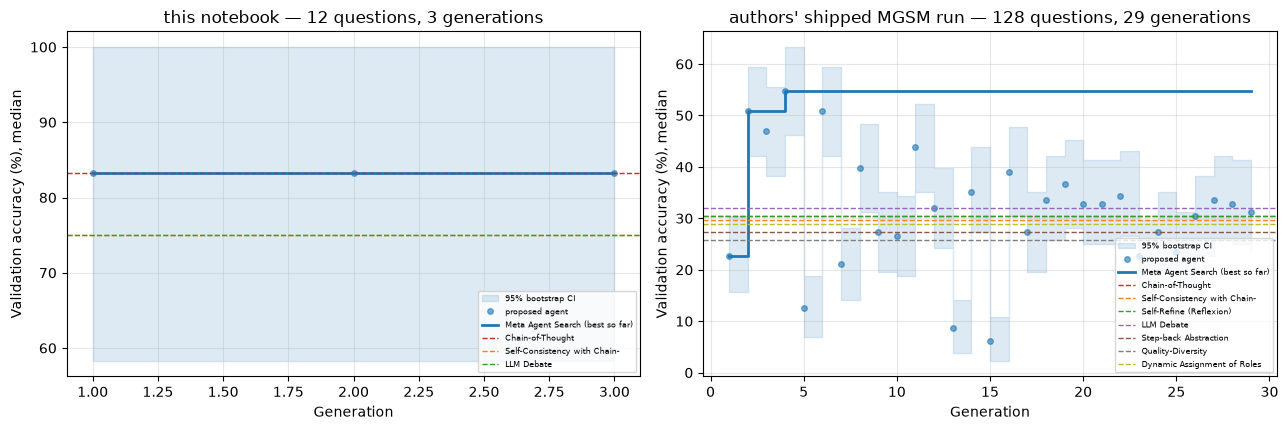

In [25]:
def progression(ax, archive, title, key="fitness"):
    archive = [s for s in archive if X.parse_fitness(s.get(key))]
    seeds = [s for s in archive if s.get("generation") == "initial"]
    gens  = [s for s in archive if s.get("generation") != "initial"]
    xs = list(range(1, len(gens) + 1))
    med = [X.parse_fitness(s.get(key))["med"] for s in gens]
    lo  = [X.parse_fitness(s.get(key))["lo"] for s in gens]
    hi  = [X.parse_fitness(s.get(key))["hi"] for s in gens]
    ax.fill_between(xs, lo, hi, alpha=0.15, color="tab:blue", step="post", label="95% bootstrap CI")
    ax.plot(xs, med, "o", ms=4, color="tab:blue", alpha=0.6, label="proposed agent")
    ax.step(xs, X.best_so_far(med), where="post", color="tab:blue", lw=2, label="Meta Agent Search (best so far)")
    for c, s in zip(["tab:red", "tab:orange", "tab:green", "tab:purple", "tab:brown", "tab:gray", "tab:olive"], seeds):
        ax.axhline(X.parse_fitness(s[key])["med"], ls="--", lw=1, color=c, label=s["name"][:28])
    ax.set_xlabel("Generation"); ax.set_ylabel("Validation accuracy (%), median")
    ax.set_title(title); ax.legend(fontsize=6, loc="lower right"); ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
progression(axes[0], RUN, f"this notebook — {EVAL_N} questions, {len(RUN)-len(SEED_NAMES)} generations")
progression(axes[1], PAPER_ARCHIVE, "authors' shipped MGSM run — 128 questions, 29 generations")
plt.tight_layout(); plt.show()

In [26]:
DISCOVERED = [s for s in RUN if s.get("generation") != "initial"]
BEST = max(DISCOVERED, key=lambda s: X.parse_fitness(s["fitness"])["med"])
BEST_SEED = max([s for s in RUN if s.get("generation") == "initial"], key=lambda s: X.parse_fitness(s["fitness"])["med"])
md(f"**Best discovered agent · {BEST['name']}** (generation {BEST['generation']}, fitness {X.fitness_pm(BEST['fitness'])})\n\n"
   f"> {' '.join(BEST['thought'].split())[:900]}\n\n```python\n{BEST['code'].strip()}\n```")
print("best seed in the archive:", BEST_SEED["name"], X.fitness_pm(BEST_SEED["fitness"]))

**Best discovered agent · Verifier-Refiner** (generation 1, fitness 83.3 ± 20.9)

> **Insights:** The Verifier-Refiner architecture adds a critical feedback loop that can correct mistakes. I will refine the instructions to ensure reliable output parsing and make the verifier's role more explicit. **Overall Idea:** An initial CoT generates a solution, then a verifier checks it; if incorrect, a refiner revises based on feedback. This repeats for up to 2 rounds. **Implementation:** - Use clear output field descriptions to enforce exact JSON keys. - For the verifier, instruct is_correct to be exactly 'yes' or 'no'. - For the refiner, include the feedback Info in the input list. - Loop up to 2 iterations, breaking when verifier says 'yes'. - Return the latest answer after the loop.

```python
def forward(self, taskInfo):
    # Initial reasoning via Chain-of-Thought
    cot_instruction = "Please think step by step and then solve the task."
    cot_agent = LLMAgentBase(['thinking', 'answer'], 'Chain-of-Thought Agent')
    thinking, answer = cot_agent([taskInfo], cot_instruction)

    # Verifier to check correctness
    verifier_instruction = (
        "You are a strict math verifier. Given the solution (thinking and answer), check if it is correct. "
        "Provide detailed feedback on any errors. Your 'is_correct' field must be EXACTLY 'yes' or 'no' (lowercase)."
    )
    verifier_agent = LLMAgentBase(['feedback', 'is_correct'], 'Verifier', role='Math Professor', temperature=0.2)

    # Refiner to revise based on feedback
    refiner_instruction = (
        "You are a careful refiner. You are given the original problem, the previous solution, and feedback from a verifier. "
        "Revise the solution to correct any mistakes. Think step by step and provide an updated answer."
    )
    refiner_agent = LLMAgentBase(['thinking', 'answer'], 'Refiner', role='Grade School Teacher', temperature=0.4)

    max_rounds = 2
    current_thinking = thinking
    current_answer = answer

    for round_idx in range(max_rounds):
        # Get verification results
        feedback_info, is_correct_info = verifier_agent([taskInfo, current_thinking, current_answer], verifier_instruction)
        is_correct = is_correct_info.content.strip().lower()
        if is_correct == 'yes':
            break
        # Refine if incorrect
        new_thinking, new_answer = refiner_agent([taskInfo, current_thinking, current_answer, feedback_info], refiner_instruction)
        current_thinking = new_thinking
        current_answer = new_answer

    return current_answer
```

best seed in the archive: Chain-of-Thought 83.3 ± 20.9


## 7 · Transfer to held-out questions and to another dataset (Sec. 4.3, Table 2; Appendix A Table 4)

> "we transfer discovered agents from the MGSM (Math) domain to both math and non-math domains to test their ability to generalize across different tasks... our agents improve accuracy by 25.9% on GSM8K and 13.2% on GSM-Hard compared to the baselines when transferring within math domains." — Sec. 4.3

Two transfers are run here with the **same** `evaluate_forward_fn`, one agent's code moved unchanged:

* **held-out MGSM** — setting `SEARCHING_MODE = False` switches the slice from `examples[:valid_size]` to `examples[valid_size:valid_size+test_size]`, the repo's own train/test separation (the paper: 128 validation / 800 test).
* **SVAMP** (Patel et al., 2021), one of the held-out math datasets in Appendix A Table 4, formatted with the authors' own transfer-domain code from `_transfer_math/SVAMP_utils.py` and injected through `adas_extras.examples_override`.

The comparison is the paper's: the discovered agent against the best hand-designed seed, on data neither of them was searched on.

In [27]:
show_source(X.examples_override)
SVAMP = X.svamp_examples(VENDOR, TRANSFER_N, seed=0)
display(df([{"question": e["inputs"].replace(chr(10), " ")[:110], "target": e["targets"]} for e in SVAMP[:4]]))

**examples_override**

```python
@contextmanager
def examples_override(search_mod, examples: list[dict]):
    """Temporarily swap the domain's example loader used by ``evaluate_forward_fn``.

    ``evaluate_forward_fn`` reads its questions from ``get_all_examples()`` in the search
    module's globals, so overriding that name lets the *unmodified* evaluation path score an
    agent on a different task set — this is how Sec. 4.3's transfer experiments are run here.
    """
    original = search_mod.get_all_examples
    search_mod.get_all_examples = lambda: list(examples)
    try:
        yield
    finally:
        search_mod.get_all_examples = original

```

,question,target
0,Solve this math problem: Every day Ryan spends...,5
1,Solve this math problem: At the arcade Dave ha...,2
2,Solve this math problem: Emily is making bead ...,16
3,Solve this math problem: Tiffany was collectin...,10


In [28]:
# held-out MGSM: keep valid_size at the value the search used, so the slice
# examples[valid_size : valid_size+test_size] cannot overlap the questions searched on.
HELD = X.make_args(valid_size=EVAL_N, test_size=TRANSFER_N, max_workers=TRANSFER_N, model=ARGS.model)
TA   = X.make_args(valid_size=TRANSFER_N, test_size=TRANSFER_N, max_workers=TRANSFER_N, model=ARGS.model)
held_q = X.mgsm_examples(S, HELD, "test")
print("held-out MGSM questions:", [f"{e['lang']}:{e['targets']}" for e in held_q])
CANDIDATES = [("discovered: " + BEST["name"], BEST), ("seed: " + BEST_SEED["name"], BEST_SEED)]
transfer_rows = []
for label, sol in CANDIDATES:
    row = {"agent": label, "MGSM validation (searched on)": X.fitness_pm(sol["fitness"])}
    S.SEARCHING_MODE = False                      # held-out slice: examples[valid_size:valid_size+test_size]
    acc = S.evaluate_forward_fn(HELD, sol["code"])
    row["MGSM held-out"] = X.fitness_pm(S.bootstrap_confidence_interval(acc))
    S.SEARCHING_MODE = True
    with X.examples_override(S, SVAMP):           # transfer domain, identical evaluation path
        acc = S.evaluate_forward_fn(TA, sol["code"])
    row["SVAMP transfer"] = X.fitness_pm(S.bootstrap_confidence_interval(acc))
    transfer_rows.append(row)
    print(label, "->", row)
display(df(transfer_rows))

held-out MGSM questions: ['es:21', 'th:80', 'ja:60', 'zh:163', 'de:2,125', 'de:163', 'es:75', 'es:10']
problem length: 8


acc: 95% Bootstrap Confidence Interval: (37.5%, 100.0%), Median: 75.0%


problem length: 8


acc: 95% Bootstrap Confidence Interval: (37.5%, 100.0%), Median: 75.0%


discovered: Verifier-Refiner -> {'agent': 'discovered: Verifier-Refiner', 'MGSM validation (searched on)': '83.3 ± 20.9', 'MGSM held-out': '75.0 ± 31.2', 'SVAMP transfer': '75.0 ± 31.2'}
problem length: 8


acc: 95% Bootstrap Confidence Interval: (62.5%, 100.0%), Median: 87.5%


problem length: 8


acc: 95% Bootstrap Confidence Interval: (62.5%, 100.0%), Median: 87.5%


seed: Chain-of-Thought -> {'agent': 'seed: Chain-of-Thought', 'MGSM validation (searched on)': '83.3 ± 20.9', 'MGSM held-out': '87.5 ± 18.8', 'SVAMP transfer': '87.5 ± 18.8'}


,agent,MGSM validation (searched on),MGSM held-out,SVAMP transfer
0,discovered: Verifier-Refiner,83.3 ± 20.9,75.0 ± 31.2,75.0 ± 31.2
1,seed: Chain-of-Thought,83.3 ± 20.9,87.5 ± 18.8,87.5 ± 18.8


With 10–12 questions per cell the 95% intervals are ±25 points or more, so these numbers cannot separate the agents; the point demonstrated is that a `forward()` discovered on MGSM runs unchanged on a different math dataset through the identical evaluation function, which is the mechanical claim underlying Sec. 4.3.

## 8 · LIVE `pi` session: a coding agent as the meta agent (Sec. 3)

> "with recent FMs being increasingly proficient in coding, we can use FMs as meta agents to create new agents in code for ADAS, enabling novel agents to be programmed in an automated manner." — Sec. 2

In the paper the meta agent is a single chat completion that must emit a complete `forward()` as a JSON string, blind: it never runs the code, and only sees an error message if evaluation fails. Here the same role is given to a **coding agent with tools** (`common.run_pi`, allowlist `read,bash,edit,write`, ephemeral, in a scratch directory). Its workspace contains exactly what the paper's prompt contains, as files:

* `FRAMEWORK.md` — the framework/utility code (part 2 of the meta-agent prompt),
* `ARCHIVE.md` — every archived agent with its `thought`, `code` and `fitness` (part 3),
* `evaluate_agent.py` — the repo's `evaluate_forward_fn` + `bootstrap_confidence_interval` behind a CLI, so the agent can *run* the evaluation itself.

The difference from the API meta agent is the loop: pi writes `new_agent.py`, executes the evaluator, reads the traceback or the fitness, and edits — the debug reflection of §5, but driven by the agent's own tool calls instead of by `search()`. Its result is then re-scored below on the same 12-question validation set used everywhere else, so it can be compared with the API-driven meta agent.

In [29]:
PI_DIR = OUT / "pi_meta"
PI_N, PI_TIMEOUT = (3, 420) if QUICK else (5, 600)   # questions the pi session scores itself on
_a = meta_prompt.find("```python") + len("```python")
_b = meta_prompt.find("# Discovered architecture archive")
FRAMEWORK_CODE = meta_prompt[_a:_b].rstrip().rstrip("`").rstrip()
files = X.write_pi_workspace(PI_DIR, repo=VENDOR, nb_dir=os.path.abspath("."), env_file=common.REPO_ROOT / ".env",
                             archive=RUN, framework_code=FRAMEWORK_CODE,
                             n_questions=PI_N, seed=ARGS.shuffle_seed)
for k, v in files.items():
    print(f"{k:10s} {v.relative_to(common.NB_DIR)}  ({v.stat().st_size} bytes)")
print()
print(files["evaluate"].read_text())

archive    outputs/adas/pi_meta/ARCHIVE.md  (14340 bytes)
framework  outputs/adas/pi_meta/FRAMEWORK.md  (6416 bytes)
evaluate   outputs/adas/pi_meta/evaluate_agent.py  (1201 bytes)

"""Score one candidate agent on 5 MGSM questions (ADAS, arXiv 2408.08435).

Usage:  python evaluate_agent.py <file.py>

<file.py> must contain exactly one top-level function, `forward(self, taskInfo)`, written
against the DSL documented in FRAMEWORK.md. The script installs it on the repo's AgentSystem
and scores it with the authors' own evaluate_forward_fn / bootstrap_confidence_interval.
"""
import os, sys
os.environ.setdefault("TQDM_DISABLE", "1")
sys.path.insert(0, '/mnt/berstorage/RCP/rcp-platform/notebooks/vendor/ADAS' + "/_mgsm")
sys.path.insert(0, '/mnt/berstorage/RCP/rcp-platform/notebooks')
from dotenv import load_dotenv
load_dotenv('/mnt/berstorage/RCP/rcp-platform/.env', override=False)
from types import SimpleNamespace
import search as S

args = SimpleNamespace(valid_size=5, test_size=5, shuffle

In [30]:
PY = str(common.REPO_ROOT / ".venv" / "bin" / "python")
PI_PROMPT = f'''You are the meta agent in Meta Agent Search (ADAS). Your job is to invent ONE new agentic system, in code, that scores better than everything in the archive.

Steps, in order:
1. Read FRAMEWORK.md (the DSL you must program against) and ARCHIVE.md (agents already tried, with their fitness).
2. Write a NEW, interesting agent into new_agent.py. The file must contain EXACTLY ONE top-level definition: `def forward(self, taskInfo):`. Do not import or redefine Info / LLMAgentBase / random_id, do not construct Info objects yourself, do not print, and never return an error message - always return the best answer you can (an Info, or a string).
3. Evaluate it by running:  {PY} evaluate_agent.py new_agent.py
4. If it errors, fix new_agent.py and re-run. At most 3 evaluation runs in total.
5. Finish by reporting the agent's name, one sentence on the idea, and the FITNESS line printed by the evaluator.

Be creative: combine or go beyond the archived designs rather than restating them.'''
t0 = time.time()
PI = common.run_pi(PI_PROMPT, cwd=PI_DIR, tools="read,bash,edit,write", timeout=PI_TIMEOUT, tag="pi_meta")
PI.show(max_chars=500)

**pi session** · cwd `/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/pi_meta` · 11 turns · 12 tool calls · 20355 in / 3815 out tokens · $0.0055 · 173s · exit 0

> **prompt:** You are the meta agent in Meta Agent Search (ADAS). Your job is to invent ONE new agentic system, in code, that scores better than everything in the archive.

Steps, in order:
1. Read FRAMEWORK.md (the DSL you must program against) and ARCHIVE.md (agents already tried, with their fitness).
2. Write a NEW, interesting agent into new_agent.py. The file must contain EXACTLY ONE top-level definition: `def forward(self, taskInfo):`. Do not import or redefine Info / LLMAgentBase / random_id, do not co…
- 💬 

Let me start by reading the framework and archive documentation.


- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/pi_meta/FRAMEWORK.md"}
- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/pi_meta/ARCHIVE.md"}
  - ↩ `# The agent framework you must program against
  
  Your new agent is a single top-level function `forward(self, taskInfo)`. It receives the
  question as an `Info` namedtuple and must return the answer (an `Info`, or a string).
  `Info`, `LLMAgentBase` and `random_id` already exist in the execution namespace — do NOT
  import or redefine them, do not construct `Info` objects yourself, and do not print.
  
  ```python
  from collections import namedtuple
  from typing import Union
  import numpy…`
  - ↩ `# Archive of discovered agents
  
  Each entry was scored on the same MGSM validation questions; `fitness` is the median
  and 95% bootstrap confidence interval of the accuracy. Maximise the median.
  
  ## Chain-of-Thought  (generation initial)
  fitness: 95% Bootstrap Confidence Interval: (58.3%, 100.0%), Median: 83.3%
  
  thought: By encouraging the LLM to think step by step rather than directly outputting an answer, chain-of-thought reasoning enables complex problem-solving through intermed…`
- 💬 Now let me look at the existing evaluate_agent.py and any supporting files to understand the evaluation setup:


- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/pi_meta/evaluate_agent.py"}
- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/pi_meta/utils.py"}
  - ❌ `ENOENT: no such file or directory, access '/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/pi_meta/utils.py'`
  - ↩ `"""Score one candidate agent on 5 MGSM questions (ADAS, arXiv 2408.08435).
  
  Usage:  python evaluate_agent.py <file.py>
  
  <file.py> must contain exactly one top-level function, `forward(self, taskInfo)`, written
  against the DSL documented in FRAMEWORK.md. The script installs it on the repo's AgentSystem
  and scores it with the authors' own evaluate_forward_fn / bootstrap_confidence_interval.
  """
  import os, sys
  os.environ.setdefault("TQDM_DISABLE", "1")
  sys.path.insert(0, '/mnt/b…`
- 💬 Let me look at the search module to understand how evaluate_forward_fn works:




- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/vendor/ADAS/_mgsm/search.py"}
  - ↩ `import argparse
  import copy
  import json
  import os
  import random
  import time
  from collections import namedtuple
  from concurrent.futures import ThreadPoolExecutor
  
  import backoff
  import numpy as np
  import openai
  from tqdm import tqdm
  
  from mgsm_prompt import get_init_archive, get_prompt, get_reflexion_prompt
  
  # --- RCP: talk to any OpenAI-compatible endpoint (OpenRouter) instead of api.openai.com,
  # and route every hard-coded gpt-3.5/gpt-4 model id to the project …`
- 💬 Now let me see the archive JSON to understand what's been evaluated so far:





- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/pi_meta && ls -la results/ 2>/dev/null || echo \"no results dir\""}
  - ↩ `no results dir`
- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/vendor/ADAS/_mgsm/utils.py"}
  - ↩ `import os
  import random
  import string
  from collections import namedtuple
  
  import numpy as np
  
  Example = namedtuple('Example', ['question', 'choice1', 'choice2', 'choice3', 'choice4', 'correct_index'])
  
  LANG_TO_INSTRUCTIONS = {
      "en": """Solve this math problem.
  
  {input}""",
      "bn": """এই গণিতের সমস্যাটি সমাধান করুন।
  
  {input}""",
      "de": """Löse dieses Mathematikproblem.
  
  {input}""",
      "es": """Resuelve este problema matemático.
  
  {input}""",
    …`
- 💬 Now I have a clear picture of the framework, archive, and evaluation setup. Let me analyze what's been tried and design a novel agent.

**Analysis of the archive:**
1. **CoT** (83.3%) - Single solution with step-by-step reasoning
2. **Self-Consistency CoT** (75.0%) - Multiple CoT paths + majority voting
3. **LLM Debate** (75.0%) - Multiple agents debate, final decision
4. **Verifier-Refiner** (83.3%) - CoT → verifier → refiner loop
5. **Verifier-Based Selection** (83.3%) - Multiple CoT + single …
- 🔧 `write` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/pi_meta/new_agent.py", "content": "def forward(self, taskInfo):\n    # === Recursive Decomposer ===\n    # Phase 1: Decomposer splits the problem into sub-problems\n    decomposer = LLMAgentBase(\n        ['sub_problems', 'dependencies'],\n        'Decomposer',\n        role='Expert Problem Decomposer who breaks complex math problems into 2-3 simpler sub-problems',\n        temperature=0.3\n    )\n    decompose_instruction = (\n  …
  - ↩ `Successfully wrote 3854 bytes to /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/pi_meta/new_agent.py`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/pi_meta && /mnt/berstorage/RCP/rcp-platform/.venv/bin/python evaluate_agent.py new_agent.py 2>&1", "timeout": 180}
  - ↩ `problem length: 5
  acc: 95% Bootstrap Confidence Interval: (40.0%, 100.0%), Median: 80.0%
  accuracy per question: [1, 1, 1, 0, 1]
  FITNESS: 95% Bootstrap Confidence Interval: (40.0%, 100.0%), Median: 80.0%`
- 💬 The agent scored 80.0% median (4/5 correct). This is below the 83.3% best in the archive. The issue is likely that the sub-problem parsing is fragile — when the LLM doesn't format the sub-problems in a clean way, the split logic fails and we fall back to a simple CoT.

Let me refactor to make the decomposition more robust by using numbered sub-problem queries instead of trying to parse free-form text. I'll also make the decomposition more structured:

Actually, the key problem is that my parsing…
- 🔧 `write` {"content": "def forward(self, taskInfo):\n    # === Recursive Decomposer (v2) ===\n    # Phase 1: Generate step-by-step solution, labeling each step\n    cot_instruction = \"Please think step by step and then solve the task. Label each reasoning step clearly with 'Step N:'.\"\n    primary_agent = LLMAgentBase(['thinking', 'answer'], 'PrimarySolver', temperature=0.4)\n    thinking_info, answer_info = primary_agent([taskInfo], cot_instruction)\n    thinking_text = thinking_info.content\n    final…
  - ↩ `Successfully wrote 2068 bytes to /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/pi_meta/new_agent.py`
- 🔧 `bash` {"command": "cd /mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/pi_meta && /mnt/berstorage/RCP/rcp-platform/.venv/bin/python evaluate_agent.py new_agent.py 2>&1", "timeout": 180}
  - ↩ `problem length: 5
  acc: 95% Bootstrap Confidence Interval: (100.0%, 100.0%), Median: 100.0%
  accuracy per question: [1, 1, 1, 1, 1]
  FITNESS: 95% Bootstrap Confidence Interval: (100.0%, 100.0%), Median: 100.0%`
- 💬 **100% fitness!** Perfect score on all 5 questions. Let me verify the final file state:
- 🔧 `read` {"path": "/mnt/berstorage/RCP/rcp-platform/notebooks/outputs/adas/pi_meta/new_agent.py"}
  - ↩ `def forward(self, taskInfo):
      # === Recursive Decomposer (v2) ===
      # Phase 1: Generate step-by-step solution, labeling each step
      cot_instruction = "Please think step by step and then solve the task. Label each reasoning step clearly with 'Step N:'."
      primary_agent = LLMAgentBase(['thinking', 'answer'], 'PrimarySolver', temperature=0.4)
      thinking_info, answer_info = primary_agent([taskInfo], cot_instruction)
      thinking_text = thinking_info.content
      final_answer …`
- 💬 Evaluation complete. Final report:

**Agent name:** Stepwise-Verified Correction (StepVerifier with Targeted Refinement)

**Idea:** Generate a step-by-step labeled solution, then have a strict verifier pinpoint errors in *individual steps*; if flagged, a refiner performs a targeted correction that explicitly avoids those identified mistakes (rather than blind refinement or whole-solution voting).

**FITNESS line printed by the evaluator:**
```
FITNESS: 95% Bootstrap Confidence Interval: (100.0%,…

In [31]:
print("pi-reported fitness (5 questions):", X.read_pi_fitness("\n".join(s.text for s in PI.steps)))
PI_CODE = (PI_DIR / "new_agent.py").read_text() if (PI_DIR / "new_agent.py").exists() else None
if PI_CODE:
    md(f"**Agent written by the pi meta agent**\n\n```python\n{PI_CODE.strip()}\n```")

pi-reported fitness (5 questions): 95% Bootstrap Confidence Interval: (40.0%, 100.0%), Median: 80.0%


**Agent written by the pi meta agent**

```python
def forward(self, taskInfo):
    # === Recursive Decomposer (v2) ===
    # Phase 1: Generate step-by-step solution, labeling each step
    cot_instruction = "Please think step by step and then solve the task. Label each reasoning step clearly with 'Step N:'."
    primary_agent = LLMAgentBase(['thinking', 'answer'], 'PrimarySolver', temperature=0.4)
    thinking_info, answer_info = primary_agent([taskInfo], cot_instruction)
    thinking_text = thinking_info.content
    final_answer = answer_info

    # Phase 2: Step-by-step verifier - check each step independently
    verifier = LLMAgentBase(
        ['step_errors', 'overall_correct'],
        'StepVerifier',
        role='Meticulous Math Verifier who checks each step for errors',
        temperature=0.2
    )
    verify_instruction = (
        "Given the original problem, the step-by-step solution, and the final answer: "
        "1) Identify any errors in individual steps (list step numbers with errors). "
        "2) State 'overall_correct' as exactly 'yes' or 'no'. "
        "Be very strict — even small arithmetic mistakes count as errors."
    )
    errors_info, correct_info = verifier([taskInfo, thinking_info, answer_info], verify_instruction)
    is_correct = correct_info.content.strip().lower()

    # Phase 3: If incorrect, do targeted correction via second solution attempt
    # that specifically addresses the identified errors
    if is_correct != 'yes':
        refiner = LLMAgentBase(
            ['thinking', 'answer'],
            'Refiner',
            role='Math Corrector who fixes solutions with known errors',
            temperature=0.3
        )
        refine_instruction = (
            f"The previous solution had errors: {errors_info.content}. "
            "Carefully revise the solution, avoiding the identified mistakes. "
            "Think step by step and provide the corrected final answer."
        )
        thinking_new, answer_new = refiner([taskInfo, thinking_info, errors_info], refine_instruction)
        final_answer = answer_new

    return final_answer
```

In [32]:
PI_ROW = None
if PI_CODE:
    S.SEARCHING_MODE = True
    try:
        acc = S.evaluate_forward_fn(ARGS, PI_CODE)       # same EVAL_N validation questions as §2/§5/§6
        PI_ROW = {"meta agent": "pi coding agent (tools, self-run evaluator)", "agent name": "new_agent.py",
                  "fitness on the shared validation set": X.fitness_pm(S.bootstrap_confidence_interval(acc))}
    except Exception as exc:
        PI_ROW = {"meta agent": "pi coding agent", "agent name": "new_agent.py",
                  "fitness on the shared validation set": f"failed: {type(exc).__name__}: {exc}"}
rows = [{"meta agent": "API meta agent (search(), 1 call + 2 reflections)", "agent name": BEST["name"],
         "fitness on the shared validation set": X.fitness_pm(BEST["fitness"])},
        {"meta agent": "best hand-designed seed", "agent name": BEST_SEED["name"],
         "fitness on the shared validation set": X.fitness_pm(BEST_SEED["fitness"])}]
if PI_ROW: rows.append(PI_ROW)
display(df(rows))
print(f"pi session: {PI.turns} turns, {len(PI.tool_calls())} tool calls, ${PI.cost_usd:.4f}, {PI.seconds:.0f}s, exit {PI.returncode}")

problem length: 12


acc: 95% Bootstrap Confidence Interval: (58.3%, 100.0%), Median: 83.3%


,meta agent,agent name,fitness on the shared validation set
0,"API meta agent (search(), 1 call + 2 reflections)",Verifier-Refiner,83.3 ± 20.9
1,best hand-designed seed,Chain-of-Thought,83.3 ± 20.9
2,"pi coding agent (tools, self-run evaluator)",new_agent.py,83.3 ± 20.9


pi session: 11 turns, 12 tool calls, $0.0055, 173s, exit 0


## 9 · Summary

In [33]:
summary = [
 ("1", "Agent DSL (Info, LLMAgentBase)", "instantiated two agents on one MGSM question; showed the declared JSON output fields, the rendered role/format system prompt, and how one agent's Infos become '### <field> by <author>' blocks in the next agent's prompt"),
 ("2", "Seed archive + bootstrap fitness", f"{len(SEED_NAMES)} of the 7 hand-designed seeds scored on {EVAL_N} MGSM questions with the authors' evaluate_forward_fn; fitness strings in the paper's median/95%-CI format; CI boundary checks on unanimous and split data"),
 ("3", "Meta-agent prompt", f"rendered the full {len(meta_prompt)}-char prompt: domain description, framework code, JSON archive, thought/name/code output format, WRONG-implementation block"),
 ("4", "Two reflection rounds", "one proposal plus both reflections; JSON keys, the reflection texts, and the code diffs they produced"),
 ("5", "Executing model-written code", "structural guards checked on hand-built candidates (no LLM calls); the error-driven debug loop; archive JSON written in the repo's results/ format alongside the authors' shipped 36-entry MGSM archive"),
 ("6", "Meta Agent Search loop", f"resumed search() for {N_GEN} further generation(s); archive now {len(RUN)} entries; Fig. 3a-style progression plotted next to the authors' 29-generation run"),
 ("7", "Transfer (Sec. 4.3)", f"best discovered agent and the best seed re-scored on held-out MGSM and on SVAMP ({TRANSFER_N} questions each) through the same evaluation function"),
 ("8", "pi as the meta agent", f"live coding-agent session: {PI.turns} turns / {len(PI.tool_calls())} tool calls, wrote new_agent.py and ran the evaluator itself; its agent re-scored on the shared validation set"),
]
display(df([{"§": a, "building block": b, "what this run showed": c} for a, b, c in summary]))
md("**Caveats.** 12 validation questions vs the paper's 128 and 2–3 generations vs 30: every confidence interval here spans tens of points, so no ranking between agents is statistically meaningful. One cheap open model plays every role (paper: GPT-4o as meta agent, GPT-3.5 inside the agents). Generated code is executed in this kernel rather than in a container (paper Sec. 6).")

,§,building block,what this run showed
0,1,"Agent DSL (Info, LLMAgentBase)",instantiated two agents on one MGSM question; ...
1,2,Seed archive + bootstrap fitness,3 of the 7 hand-designed seeds scored on 12 MG...
2,3,Meta-agent prompt,rendered the full 16710-char prompt: domain de...
3,4,Two reflection rounds,"one proposal plus both reflections; JSON keys,..."
4,5,Executing model-written code,structural guards checked on hand-built candid...
5,6,Meta Agent Search loop,resumed search() for 2 further generation(s); ...
6,7,Transfer (Sec. 4.3),best discovered agent and the best seed re-sco...
7,8,pi as the meta agent,live coding-agent session: 11 turns / 12 tool ...


**Caveats.** 12 validation questions vs the paper's 128 and 2–3 generations vs 30: every confidence interval here spans tens of points, so no ranking between agents is statistically meaningful. One cheap open model plays every role (paper: GPT-4o as meta agent, GPT-3.5 inside the agents). Generated code is executed in this kernel rather than in a container (paper Sec. 6).

In [34]:
print(USAGE.summary())

751 requests, 326226 in / 113559 out tokens, 6024s in model calls, $0.0690; by tag: {'agent': 741, 'meta': 9, 'pi_meta': 1}
